# Universidad de Buenos Aires

# Aprendizaje Profundo - TP2

# Cohorte 24 - 2do bimestre 2026


El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**

- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.


# CASO: Adult Census Income


El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:

- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.


# EDA


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [33]:
df_train = pd.read_csv("./datasets/adult_train.csv")
df_val = pd.read_csv("./datasets/adult_val.csv")
print("Shape train", df_train.shape)
print("Shape val", df_val.shape)

Shape train (30162, 14)
Shape val (15060, 14)


In [34]:
resumen_train = pd.DataFrame(
    {
        "dtype": df_train.dtypes,
        "n_unicos": df_train.nunique(),
        "n_nulos": df_train.isnull().sum(),
        "pct_nulos": (df_train.isnull().mean() * 100).round(2),
    }
)
resumen_train

,dtype,n_unicos,n_nulos,pct_nulos
age,int64,72,0,0.0
workclass,str,7,0,0.0
education,str,16,0,0.0
marital-status,str,7,0,0.0
occupation,str,14,0,0.0
relationship,str,6,0,0.0
race,str,5,0,0.0
sex,str,2,0,0.0
capital-gain,int64,118,0,0.0
capital-loss,int64,90,0,0.0


In [35]:
resumen_val = pd.DataFrame(
    {
        "dtype": df_val.dtypes,
        "n_unicos": df_val.nunique(),
        "n_nulos": df_val.isnull().sum(),
        "pct_nulos": (df_val.isnull().mean() * 100).round(2),
    }
)
resumen_val

,dtype,n_unicos,n_nulos,pct_nulos
age,int64,73,0,0.0
workclass,str,7,0,0.0
education,str,16,0,0.0
marital-status,str,7,0,0.0
occupation,str,14,0,0.0
relationship,str,6,0,0.0
race,str,5,0,0.0
sex,str,2,0,0.0
capital-gain,int64,110,0,0.0
capital-loss,int64,79,0,0.0


Con estos resumenes podemos ver lo siguiente:

- No tenemos nulos en ninguna feature, pero una simple inspeccion visual del dataset revela que hay bastantes 0s en `capital-gain` y `capital-loss`
- Tenemos una cardinalidad bastante elevada en algunas features, por ejemplo `skill-profile` tiene 80 valores distintos. `native-country` tiene 40 valores distintos. Mientras que otras columnas muestran una cardinalidad elevada (mayor a 10) pero las más fuertes son las mencionadas anteriormente.
- Los datasets son consistentes en el aspecto que las features tienen la misma cardinalidad con la excepción de `native-country` que cuenta con 41 valores únicos en train y 40 en val.


In [36]:
dup_train = df_train.duplicated().sum()
dup_val = df_val.duplicated().sum()

duplicate_percentage_train = (dup_train / len(df_train)) * 100
duplicate_percentage_val = (dup_val / len(df_val)) * 100


print(
    "Registros duplicados en train dataset",
    dup_train,
    f"{duplicate_percentage_train:.2f} %",
)
print(
    "Registros duplicados en val dataset", dup_val, f"{duplicate_percentage_val:.2f} %"
)

Registros duplicados en train dataset 479 1.59 %
Registros duplicados en val dataset 118 0.78 %


Tenemos unos cuantos registros duplicados pero serán realmente duplicados (error de carga)? En este datasets de informacion censal los duplicados pueden suceder (dos personas con características idénticas)

Lo que hay que tener cuidado, es si hay registros duplicados en train y val; Es decir hay un registro exactamente igual en val como en train, lo cual sería data leakage.

Revisemos.


In [37]:
merged = df_train.merge(df_val, on=list(df_train.columns))
print(f"Filas en común entre train y val: {len(merged)}")

Filas en común entre train y val: 515


Esto es algo interesante, tenemos registros duplicados en los datasets de train y val y entre ambos datasets lo cual es data leakage.

Debido a que el porcentaje de duplicados intra-dataset y cross-dataset es bastante bajo, procedo a drop los duplicados y asi tenemos datasets limpios para trabajar.


In [38]:
df_train = df_train.drop_duplicates().reset_index(drop=True)
df_val = df_val.drop_duplicates().reset_index(drop=True)

print(f"Train after drop: {len(df_train)}")
print(f"Val after drop: {len(df_val)}")

# remove from val any row that also appears in train
train_tuples = set(df_train.apply(tuple, axis=1))
leakage_mask = df_val.apply(tuple, axis=1).isin(train_tuples)
print(f"Cross-set overlap removed from val: {leakage_mask.sum()}")
df_val = df_val[~leakage_mask].reset_index(drop=True)

print(f"Final train: {len(df_train)}")
print(f"Final val: {len(df_val)}")

Train after drop: 29683
Val after drop: 14942
Cross-set overlap removed from val: 384
Final train: 29683
Final val: 14558


Revisemos.


In [39]:
# no duplicates in datasets
assert df_train.duplicated().sum() == 0, "Train still has duplicates"
assert df_val.duplicated().sum() == 0, "Val still has duplicates"

# no cross duplicates
train_tuples = set(df_train.apply(tuple, axis=1))
val_tuples = set(df_val.apply(tuple, axis=1))
assert (
    len(train_tuples & val_tuples) == 0
), "There are rows in common between train and val"

Revisemos valores extremos


In [40]:
# Age should be >= 18 for working adults
print("Age < 17:", (df_train["age"] < 17).sum())
# Hours per week should be 1–168
print(
    "Hours > 168:", (df_train["hours-per-week"] > 168).sum()
)  # horas de toda una semana
print("Hours == 0:", (df_train["hours-per-week"] == 0).sum())

Age < 17: 0
Hours > 168: 0
Hours == 0: 0


In [41]:
print(df_train["hours-per-week"].value_counts().sort_index().tail(10))

hours-per-week
89     2
90    28
91     3
92     1
94     1
95     2
96     5
97     2
98    11
99    78
Name: count, dtype: int64


In [42]:
cat_cols = df_train.select_dtypes("str").drop(columns="income").columns

for col in cat_cols:
    only_in_train = set(df_train[col]) - set(df_val[col])
    only_in_val = set(df_val[col]) - set(df_train[col])
    if only_in_train:
        print(f"{col} — only in train: {only_in_train}")
    if only_in_val:
        print(f"{col} — only in val: {only_in_val}")

native-country — only in train: {'Holand-Netherlands'}


Tenemos una sola categoría en train que no está en val lo cual no representa un problema.


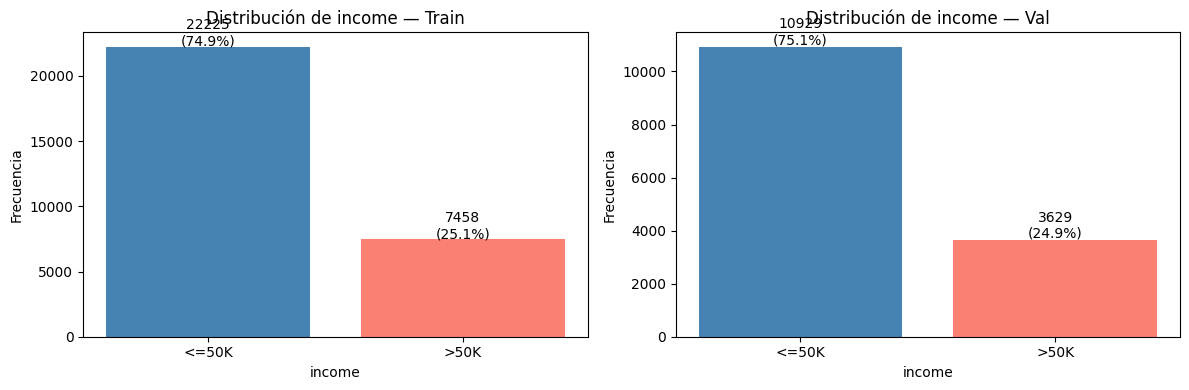

In [43]:
# Distribución del target en train y val
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, name) in zip(axes, [(df_train, "Train"), (df_val, "Val")]):
    counts = df["income"].value_counts()
    ax.bar(counts.index, counts.values, color=["steelblue", "salmon"])
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
    ax.set_title(f"Distribución de income — {name}")
    ax.set_xlabel("income")
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

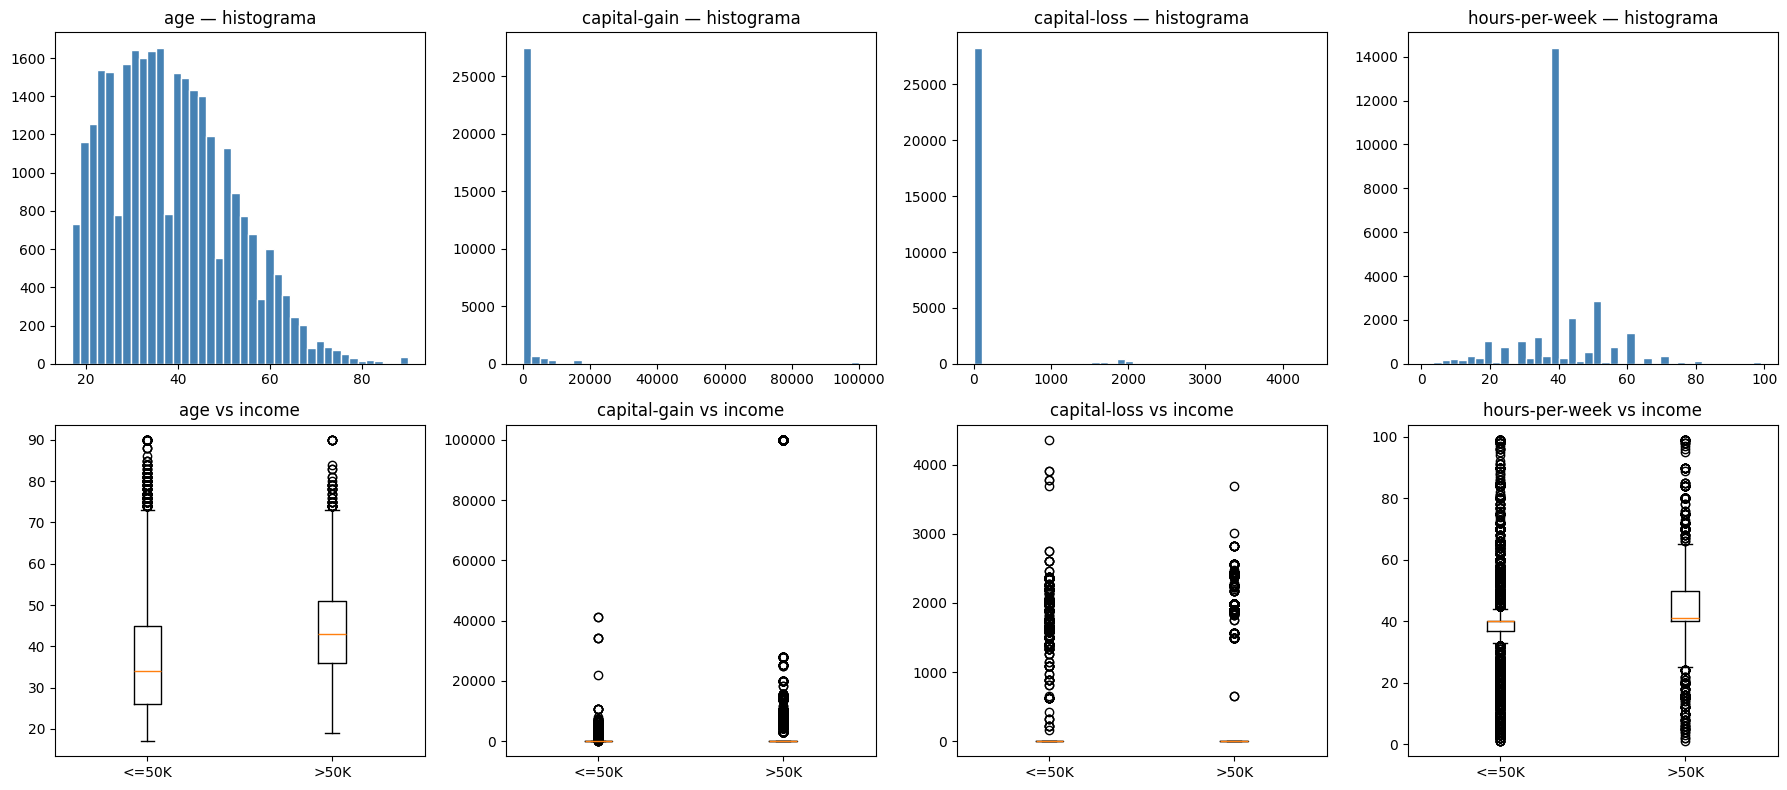

,age,capital-gain,capital-loss,hours-per-week
count,29683.000000,29683.000000,29683.000000,29683.000000
mean,38.546744,1109.629788,89.798572,40.991645
std,13.130225,7464.558413,407.390396,12.015810
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [44]:
num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df_train[col], bins=40, color="steelblue", edgecolor="white")
    axes[0, i].set_title(f"{col} — histograma")
    # Box plot by target
    groups = [df_train[df_train["income"] == cat][col] for cat in ["<=50K", ">50K"]]
    axes[1, i].boxplot(groups, tick_labels=["<=50K", ">50K"])
    axes[1, i].set_title(f"{col} vs income")
plt.tight_layout()
plt.show()

df_train[num_cols].describe()

De esto vemos lo siguiente:

- `Age` nos muestra algo común, a mayor edad la gente deja de trabajar. En el box plot vemos que personas con mayor edad consistentemente tienen mejores ingresos. Para <50k la mediana es 33 y >50k es 44.
- `capital-gain`. y `capital-loss` están bastante dominadas por ceros haciendo que el histograma y box plots sean un poco ilegibles. Lo que si podemos observar es que a mayor `capital_gain` pues mayores ingresos hay.


## Distribuciones


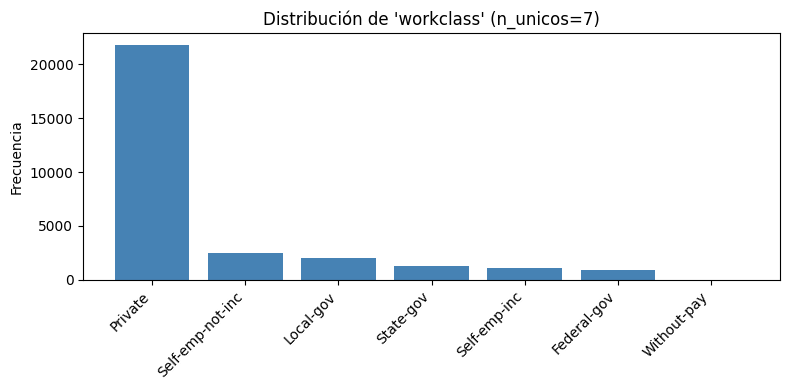

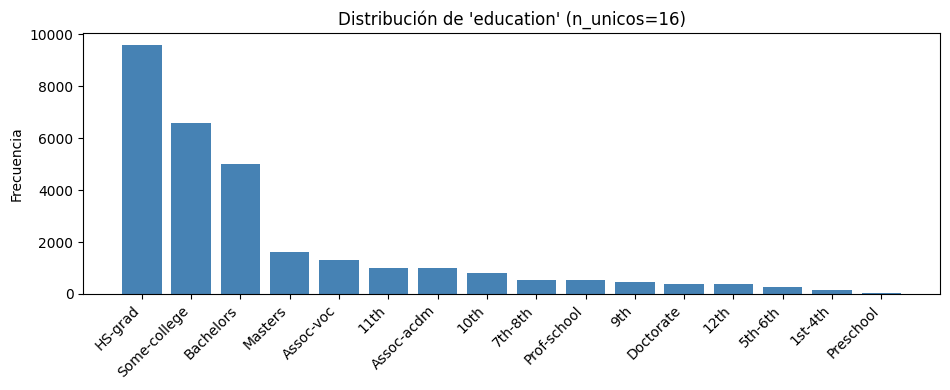

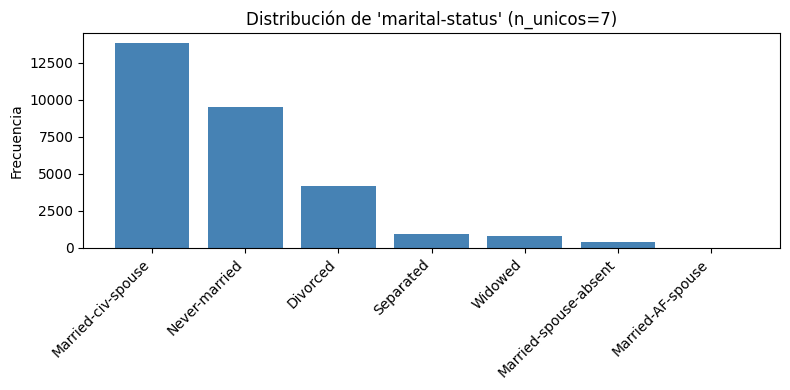

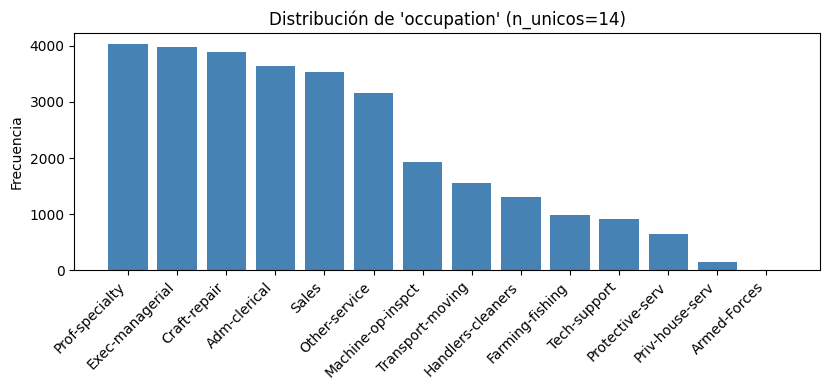

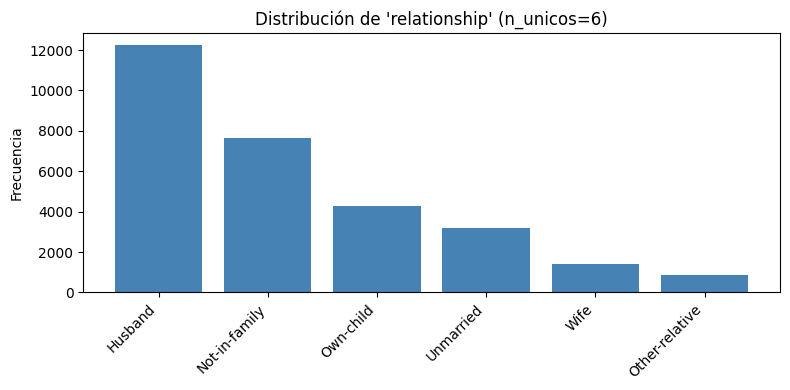

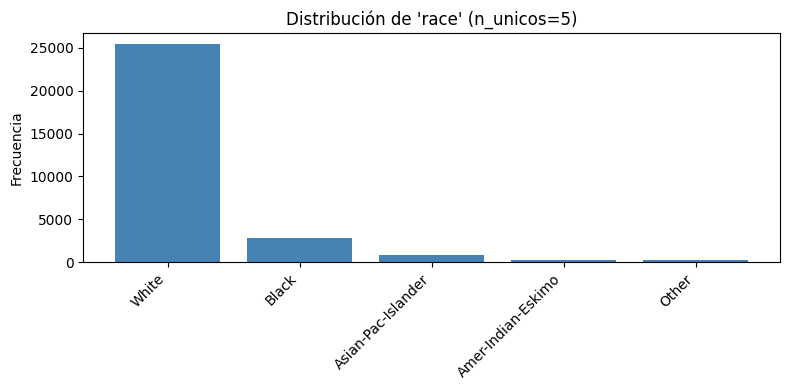

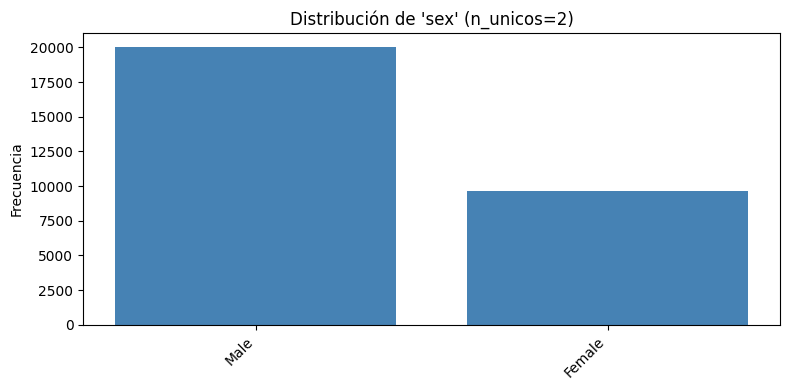

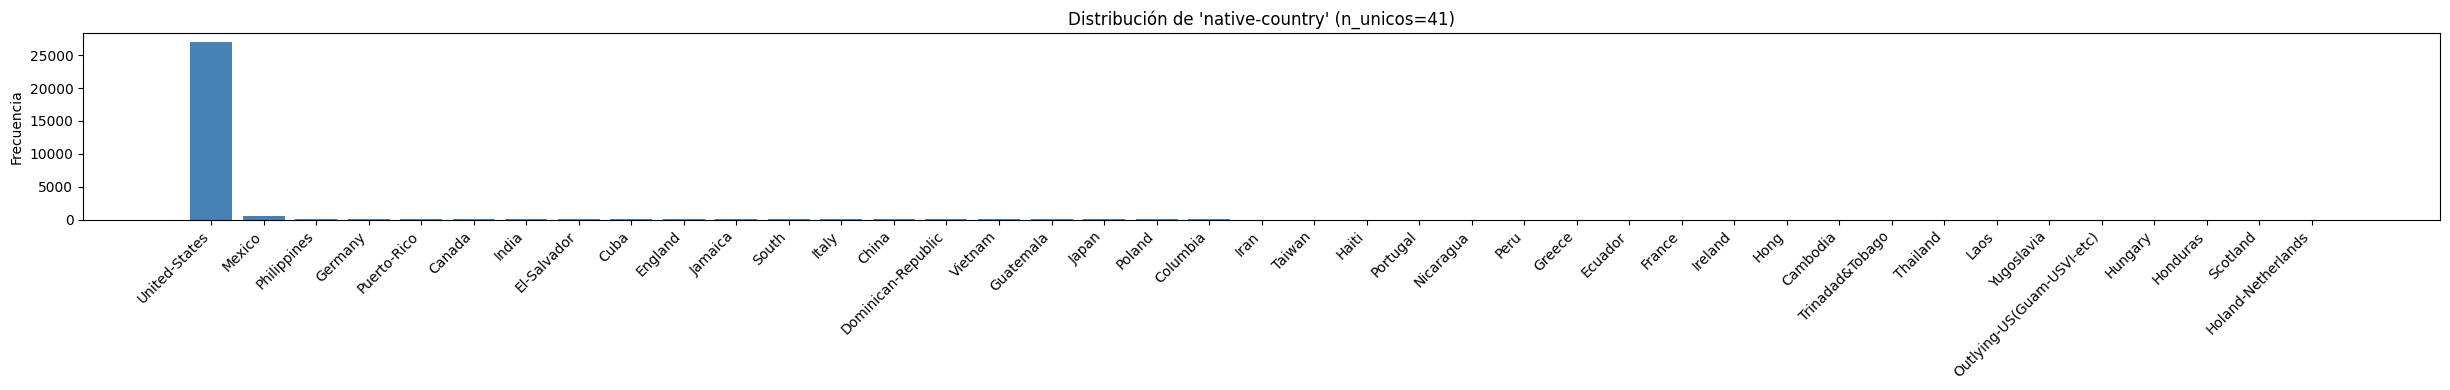

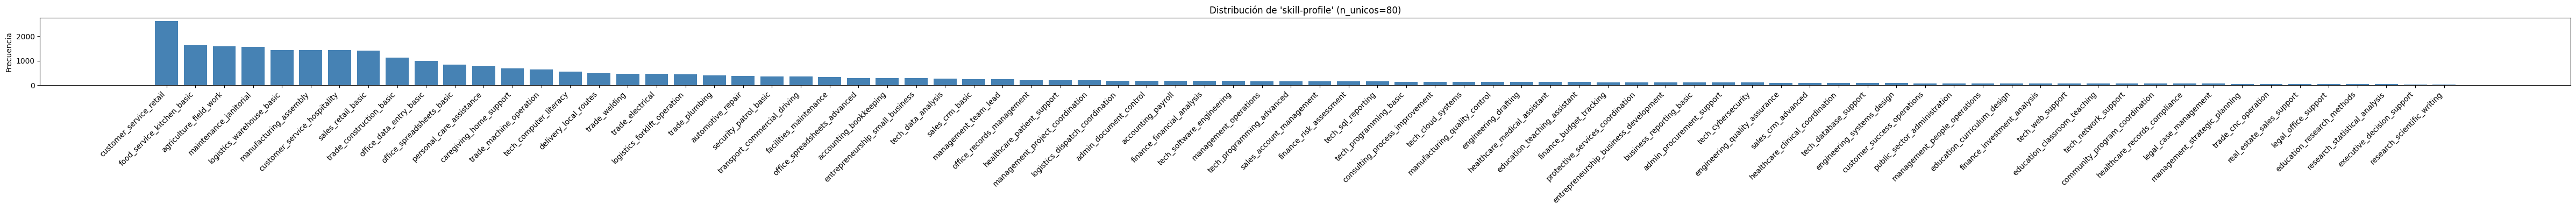

In [45]:
cat_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "skill-profile",
]


for col in cat_cols:
    vc = df_train[col].value_counts()
    fig, ax = plt.subplots(figsize=(max(8, len(vc) * 0.6), 4))
    ax.bar(range(len(vc)), vc.values, color="steelblue")
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=45, ha="right")
    ax.set_title(f"Distribución de '{col}' (n_unicos={len(vc)})")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

## Proporcion de income con las columnas categóricas

Excluyo las de alta cardinalidad debido a que se vuelve ilegible.


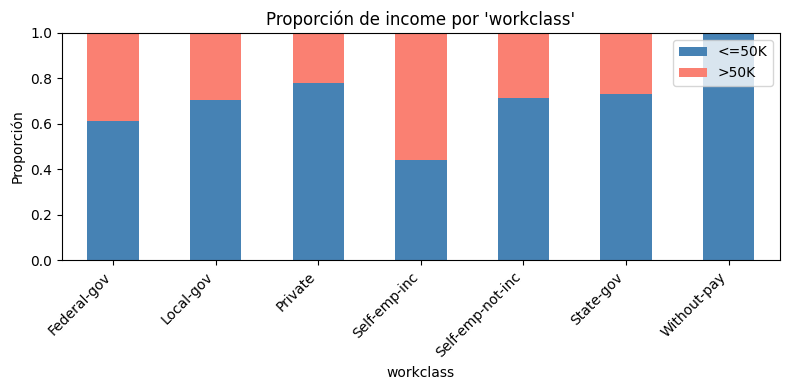

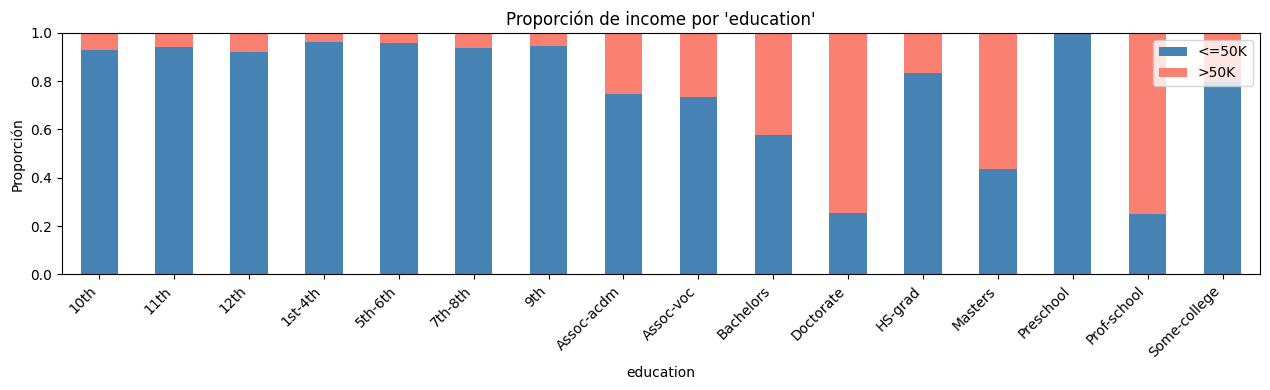

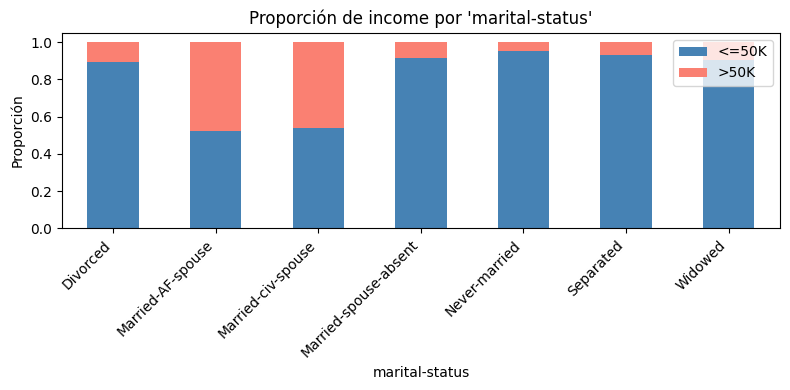

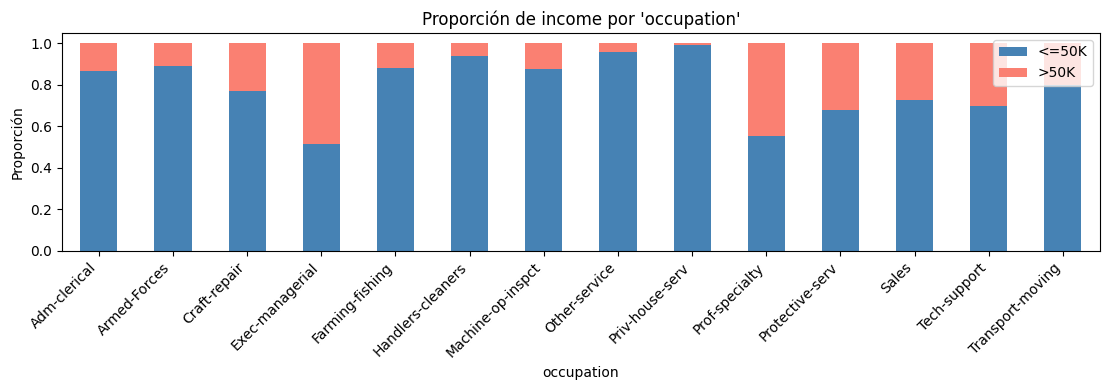

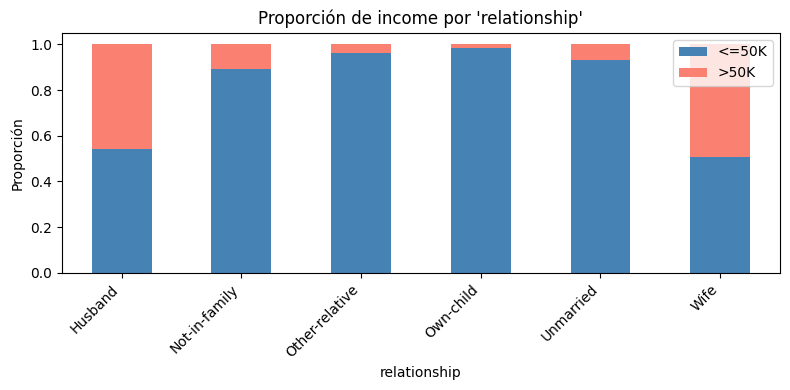

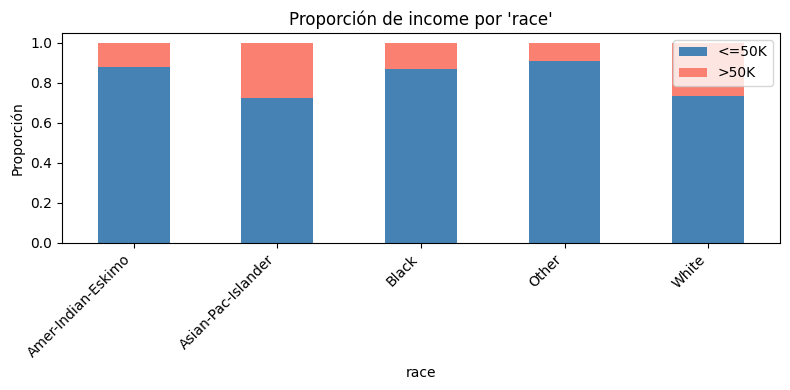

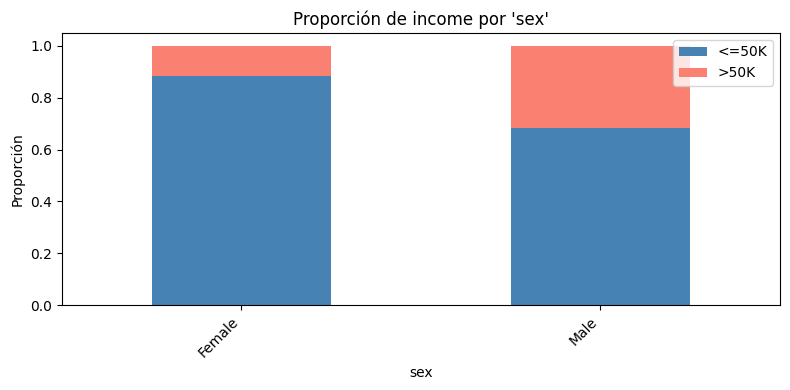

In [46]:
# Stacked bar: proportion of >50K per category
low_card_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
]

for col in low_card_cols:
    ct = pd.crosstab(df_train[col], df_train["income"], normalize="index")
    ct.plot(
        kind="bar",
        stacked=True,
        figsize=(max(8, len(ct) * 0.8), 4),
        color=["steelblue", "salmon"],
    )
    plt.title(f"Proporción de income por '{col}'")
    plt.ylabel("Proporción")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

Veamos un poco las categoricas con mayor cardinalidad, solo 15 para mantener legible las gráficas.


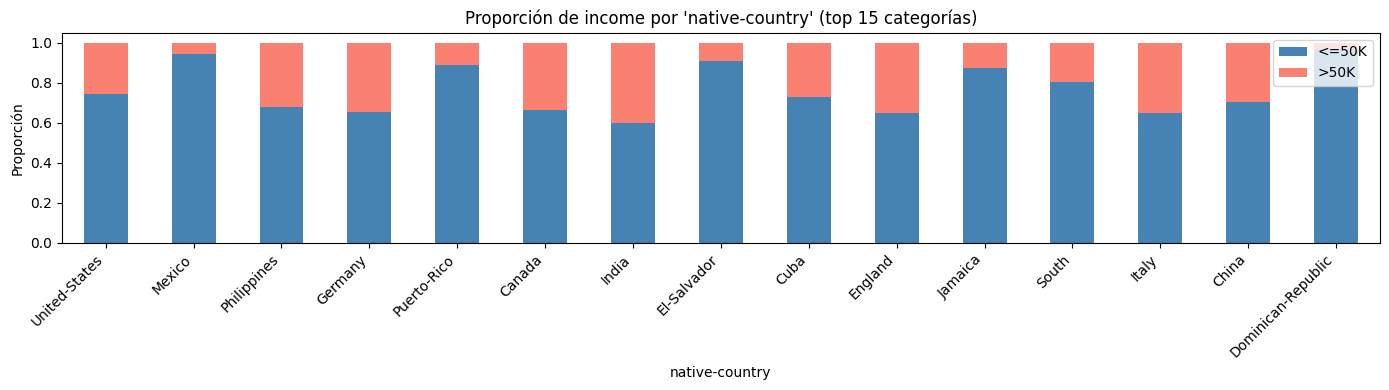

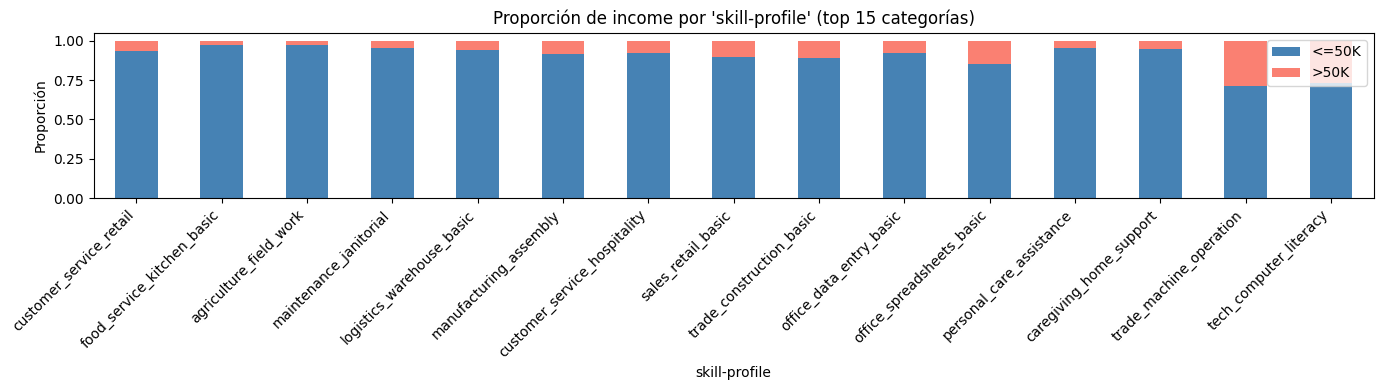

In [47]:
for col in ["native-country", "skill-profile"]:
    top15 = df_train[col].value_counts().index[:15]
    ct = pd.crosstab(df_train[col], df_train["income"], normalize="index")
    ct = ct.loc[top15]
    ct.plot(kind="bar", stacked=True, figsize=(14, 4), color=["steelblue", "salmon"])
    plt.title(f"Proporción de income por '{col}' (top 15 categorías)")
    plt.ylabel("Proporción")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

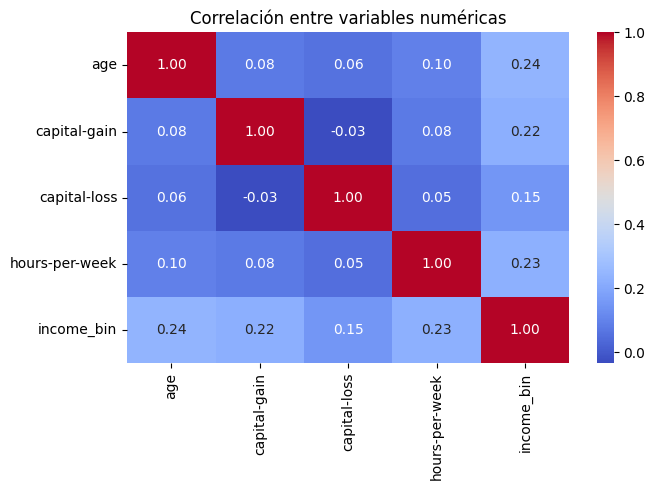

In [48]:
import seaborn as sns

corr = df_train[num_cols + ["income"]].copy()
corr["income_bin"] = (corr["income"] == ">50K").astype(int)
corr = corr.drop(columns="income")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

`age` es el predictor númerico mas fuerte aunque no tan alto.
`capital-gain` tiene una correlación alta pero recordemos que está dominado por el valor 0.

Tenemos correlaciones bajas


capital-gain: 27145 ceros (91.4%)


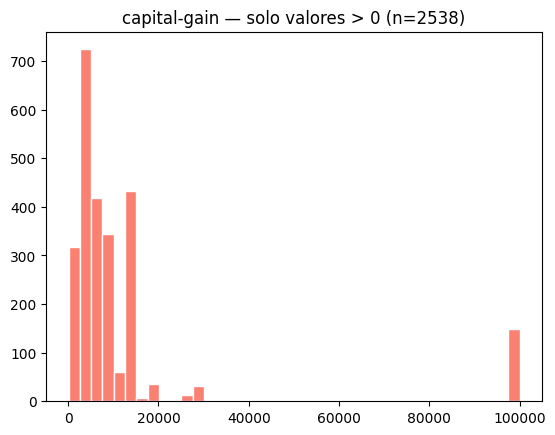

capital-loss: 28256 ceros (95.2%)


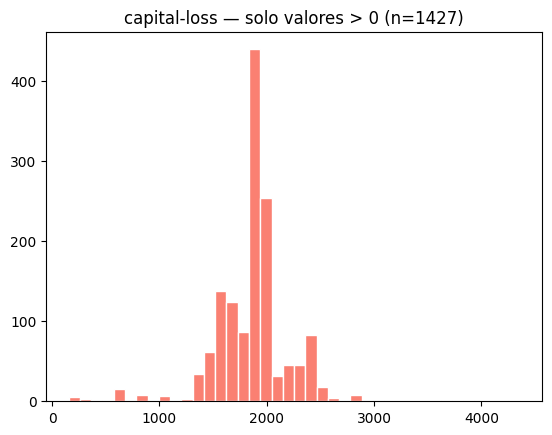

In [49]:
for col in ["capital-gain", "capital-loss"]:
    zeros = (df_train[col] == 0).sum()
    pct = zeros / len(df_train) * 100
    print(f"{col}: {zeros} ceros ({pct:.1f}%)")
    nonzero = df_train[df_train[col] > 0][col]
    plt.hist(nonzero, bins=40, color="salmon", edgecolor="white")
    plt.title(f"{col} — solo valores > 0 (n={len(nonzero)})")
    plt.show()

Aproximadamente el 9% de los registros reporta capital gains y un 5% perdidas. Tenemos un rango bastante alto. Una transformación logaritmica podria mejorar la señal de estas dos variables.


## Encodings


### Decisiones de transformación


#### Variables numéricas

- **age** - StandardScaler
  La distribución es continua y aproximadamente normal (pico en 30–35 con cola hacia 80+). No requiere transformación previa al escalado.

- **capital-gain** - log(x+1) + StandardScaler
  El 91% de los registros tiene valor 0. La distribución es fuertemente asimétrica con valores hasta$99,999. Sin transformación, StandardScaler produciría una media casi 0 y desviación estándar altísima. El log(x+1) comprime la escala antes de normalizar.

- **capital-loss** → log(x+1) + StandardScaler
  El 95% de los registros es 0. Misma problemática que capital-gain: la dominancia del cero distorsiona el escalado. Se aplica log(x+1) por la misma razón.

- **hours-per-week** → StandardScaler
  Distribución continua con pico pronunciado en 40 horas (jornada completa estándar). StandardScaler es suficiente.


In [50]:
from sklearn.preprocessing import StandardScaler

df_train_enc = df_train.copy()
df_val_enc = df_val.copy()

# log(x+1) on sparse capital variables
for col in ["capital-gain", "capital-loss"]:
    df_train_enc[col] = np.log1p(df_train_enc[col])
    df_val_enc[col] = np.log1p(df_val_enc[col])

# StandardScaler fit on train only, applied to both
num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]
scaler = StandardScaler()
df_train_enc[num_cols] = scaler.fit_transform(df_train_enc[num_cols])
df_val_enc[num_cols] = scaler.transform(df_val_enc[num_cols])

print("Numerical features scaled. Means (train, should be ~0):")
print(df_train_enc[num_cols].mean().round(4))

Numerical features scaled. Means (train, should be ~0):
age              -0.0
capital-gain      0.0
capital-loss     -0.0
hours-per-week   -0.0
dtype: float64


#### Variables categóricas binarias

- **sex** → Label encoding (Male=1, Female=0)
  Variable binaria.


In [51]:
df_train_enc["sex"] = (df_train_enc["sex"] == "Male").astype(int)
df_val_enc["sex"] = (df_val_enc["sex"] == "Male").astype(int)

print(df_train_enc["sex"].value_counts())

sex
1    20043
0     9640
Name: count, dtype: int64


#### Variables categóricas de baja cardinalidad — One-hot encoding

- **race** (5 categorías), **relationship** (6), **workclass** (7), **marital-status** (7)
  Estas variables son estrictamente nominales: no existe distancia ni jerarquía significativa entre sus categorías. El gráfico de proporciones muestra que cada categoría tiene un perfil de income distinto e independiente (por ejemplo, en `relationship`, "Husband" tiene ~45% >50K mientras "Own-child" tiene <5%). One-hot encoding preserva esta independencia correctamente, mientras que asignar enteros arbitrarios introduciría un orden artificial que el modelo podría malinterpretar. Con menos de 10 categorías cada una, el costo en dimensionalidad es manejable.


In [52]:
from sklearn.preprocessing import OneHotEncoder

ohe_cols = ["workclass", "marital-status", "relationship", "race"]
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", dtype=np.float32)
ohe.fit(df_train_enc[ohe_cols])

ohe_train = pd.DataFrame(
    ohe.transform(df_train_enc[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols)
)
ohe_val = pd.DataFrame(
    ohe.transform(df_val_enc[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols)
)

print(f"OHE output shape — train: {ohe_train.shape}, val: {ohe_val.shape}")
print("Columns:", list(ohe.get_feature_names_out(ohe_cols)))

OHE output shape — train: (29683, 25), val: (14558, 25)
Columns: ['workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital-status_Divorced', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'relationship_Husband', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White']


#### Variable categórica de alta cardinalidad con orden — Ordinal encoding

- **education** (16 categorías) - Ordinal encoding
  A diferencia del resto de variables categóricas, `education` tiene un orden educativo universalmente reconocido (Preschool < 1st-4th < ... < Bachelors < Masters < Doctorate). El gráfico de proporciones confirma que este orden se alinea con el comportamiento del target: la proporción de >50K aumenta de forma general al subir en el nivel educativo (desde ~2% en Preschool hasta ~75% en Doctorate y Prof-school). Si bien la relación no es perfectamente monótona (Doctorate ≈ Prof-school, y hay individuos de bajo nivel educativo con altos ingresos), la tendencia general es clara.

  Sin embargo, hacer ordinal encoding requiere de tener conocimiento acerca del sistema educativo de donde se basa el dataset. Algunos niveles son facilmente reconocibles pero `Assoc-voc`, `Assoc-acdm` no dicen mucho a simple vista el nivel educativo en el que están. Además, `prof-school` no parece ser algo como más alto que `masters`. Por ende, el orden elegido en la siguiente cell puede estar sesgada por mi propia interpretación e investigación de estos niveles educativos. Se deja como abierto a experimentar con embeddings en lugar de ordinal encoding.


In [53]:
from sklearn.preprocessing import LabelEncoder

EDUCATION_AS_EMBEDDING = False

if EDUCATION_AS_EMBEDDING:
    le_education = LabelEncoder()
    df_train_enc["education"] = le_education.fit_transform(df_train_enc["education"])
    df_val_enc["education"] = le_education.transform(df_val_enc["education"])
    print(f"education: embedding mode — {len(le_education.classes_)} índices")
else:
    education_order = [
        "Preschool",
        "1st-4th",
        "5th-6th",
        "7th-8th",
        "9th",
        "10th",
        "11th",
        "12th",
        "HS-grad",
        "Some-college",
        "Assoc-voc",
        "Assoc-acdm",
        "Bachelors",
        "Masters",
        "Prof-school",
        "Doctorate",
    ]
    edu_map = {cat: i for i, cat in enumerate(education_order)}
    df_train_enc["education"] = df_train_enc["education"].map(edu_map)
    df_val_enc["education"] = df_val_enc["education"].map(edu_map)
    assert (
        df_train_enc["education"].isna().sum() == 0
    ), "Unknown education category in train"
    assert (
        df_val_enc["education"].isna().sum() == 0
    ), "Unknown education category in val"
    print(
        f"education: ordinal mode — rango {df_train_enc['education'].min()}–{df_train_enc['education'].max()}"
    )

education: ordinal mode — rango 0–15


#### Variables categóricas de alta cardinalidad sin orden — Embeddings

- **occupation** (14 categorías) - Embedding
  El gráfico de proporciones muestra alta variabilidad en tasas de income entre ocupaciones. Las ocupaciones tienen proximidad semántica: categorías como "Exec-managerial" y "Prof-specialty" probablemente comparten un espacio de representación similar en términos de ingresos. Un embedding aprende representaciones densas que pueden capturar estas relaciones durante el entrenamiento.

- **native-country** (41 categorías) - Embedding
  La distribución es extremadamente desbalanceada: la gran mayoría de observaciones corresponden a "United-States", con decenas de países representados por muy pocas filas. One-hot generaría 41 columnas donde la mayoría son casi ceros, sin señal suficiente para aprender pesos útiles. En particular, "Holand-Netherlands" tiene un único registro en train y ninguno en val: dedicarle una columna entera con OHE es ineficiente. Los embeddings permiten que categorías raras compartan capacidad representacional con categorías similares, manejando mejor el desbalance de frecuencias.

- **skill-profile** (80 categorías) - Embedding
  Con 80 categorías únicas, OHE produciría 80 columnas binarias donde cada fila tendría 79 ceros y un solo 1 — el caso de uso exacto que los embeddings resuelven. Además, los perfiles de habilidad tienen agrupaciones semánticas naturales (e.g., `tech_programming_advanced` y `tech_programming_basic` deberían ser cercanos en el espacio de representación). Un embedding puede capturar estas similitudes.


In [54]:
from sklearn.preprocessing import LabelEncoder

emb_cols = ["occupation", "native-country", "skill-profile"]
label_encoders = {}

for col in emb_cols:
    le = LabelEncoder()
    df_train_enc[col] = le.fit_transform(df_train_enc[col])
    df_val_enc[col] = le.transform(df_val_enc[col])
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} categorías → índices 0–{len(le.classes_)-1}")

occupation: 14 categorías → índices 0–13
native-country: 41 categorías → índices 0–40
skill-profile: 80 categorías → índices 0–79


In [55]:
inplace_cols = [
    "age",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "sex",
    "education",
] + emb_cols


X_train = pd.concat(
    [
        df_train_enc[inplace_cols].reset_index(drop=True),
        ohe_train.reset_index(drop=True),
    ],
    axis=1,
)

X_val = pd.concat(
    [df_val_enc[inplace_cols].reset_index(drop=True), ohe_val.reset_index(drop=True)],
    axis=1,
)

# Binary target
y_train = (df_train_enc["income"] == ">50K").astype(int).reset_index(drop=True)
y_val = (df_val_enc["income"] == ">50K").astype(int).reset_index(drop=True)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(
    f"\nTarget distribution (train): {y_train.value_counts(normalize=True).mul(100).round(2).to_dict()}"
)

X_train: (29683, 34) | y_train: (29683,)
X_val:   (14558, 34) | y_val:   (14558,)

Target distribution (train): {0: 74.87, 1: 25.13}


Algo que no se ha mencionado es que tenemos un dataset moderadamente desbalanceado

Aproximadamente con 75% para <50K y 25% para >50k


In [56]:
assert X_train.isna().sum().sum() == 0, "NaN found in X_train"
assert X_val.isna().sum().sum() == 0, "NaN found in X_val"
assert X_train.shape[1] == X_val.shape[1], "Column mismatch between train and val"
assert set(y_train.unique()) == {0, 1}, "Target is not binary"
print("All assertions passed.")

All assertions passed.


## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.


### Dataset


In [57]:
import torch
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)  # para Apple Silicon
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

emb_col_names = ["occupation", "native-country", "skill-profile"]
if EDUCATION_AS_EMBEDDING:
    emb_col_names = emb_col_names + ["education"]

dense_col_names = [c for c in X_train.columns if c not in emb_col_names]


class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X_dense = torch.tensor(X[dense_col_names].values, dtype=torch.float32)
        self.X_occ = torch.tensor(X["occupation"].values, dtype=torch.long)
        self.X_country = torch.tensor(X["native-country"].values, dtype=torch.long)
        self.X_skill = torch.tensor(X["skill-profile"].values, dtype=torch.long)
        self.X_edu = torch.tensor(X["education"].values, dtype=torch.long)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return (
            self.X_dense[index],
            self.X_occ[index],
            self.X_country[index],
            self.X_skill[index],
            self.X_edu[index],
            self.y[index],
        )


train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(
    f"Dense features: {len(dense_col_names)} | education as embedding: {EDUCATION_AS_EMBEDDING}"
)

Train batches: 58 | Val batches: 29
Dense features: 31 | education as embedding: False


### Diseño del modelo


Las dimensiones de mis embeddings elijo algo empirico como `cardinalidad // 2`. Estos hiperparametros lo dejo abierto a experimenticación dependiendo del rendimiento del modelo.

Por ejemplo en un blog de tensorflow se menciona esto

https://developers.googleblog.com/introducing-tensorflow-feature-columns/
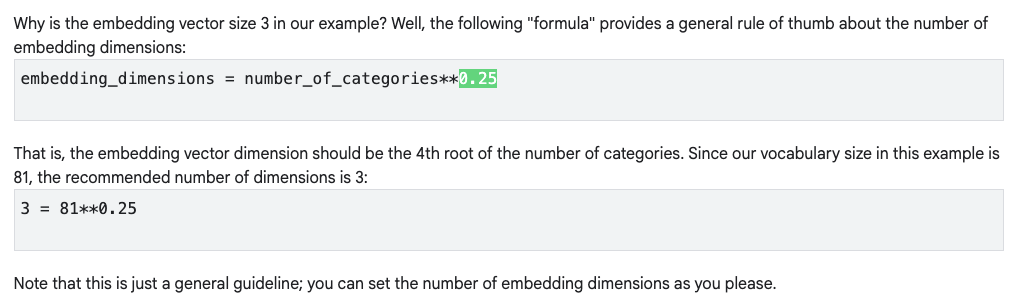

#### Arquitectura del modelo inicial

2 capas ocultas + 1 capa de salida, con anchos decrecientes 99 - 128 - 64 - 1

- Capa 1 - Linear(99 - 128), activación Relu, Dropout(0.3)
- Capa 2 - Linear(128 - 64), activación Relu, Dropout(0.3)
- Capa de salida - Linear(64 - 1), sin activación

Se elige esta arquitectura inicial de 2 capas ocultas. Si el modelo underfitea, probamos con más capas.


In [58]:
import torch.nn as nn
import torch.nn.functional as F


class IncomeModelEmbedding(nn.Module):
    def __init__(self):
        super().__init__()

        self.emb_occ = nn.Embedding(14, 7)
        self.emb_country = nn.Embedding(41, 21)
        self.emb_skill = nn.Embedding(80, 40)

        if EDUCATION_AS_EMBEDDING:
            self.emb_edu = nn.Embedding(16, 8)
            fc1_input = len(dense_col_names) + 7 + 21 + 40 + 8  # 106
        else:
            self.emb_edu = None
            fc1_input = len(dense_col_names) + 7 + 21 + 40  # 99

        self.fc1 = nn.Linear(fc1_input, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x_dense, x_occ, x_country, x_skill, x_edu):
        e_occ = self.emb_occ(x_occ)
        e_country = self.emb_country(x_country)
        e_skill = self.emb_skill(x_skill)

        parts = [x_dense, e_occ, e_country, e_skill]
        if EDUCATION_AS_EMBEDDING:
            parts.append(self.emb_edu(x_edu))

        x = torch.cat(parts, dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = IncomeModelEmbedding().to(device)
print(model)
print("device", device)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

IncomeModelEmbedding(
  (emb_occ): Embedding(14, 7)
  (emb_country): Embedding(41, 21)
  (emb_skill): Embedding(80, 40)
  (fc1): Linear(in_features=99, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
device mps

Total parameters: 25,280


### Entrenamiento

Debido a la naturaleza del problema cuyo target es binario se usa `BCEWithLogitsLoss` como función de costo.

Aqui haremos dos experimentos debido a que tenemos un problema desbalanceado:

- Experimento 1: Entrenaremos un modelo sin ningun tratamiento de desbalance
- Experimento 2: Entrenaremos un segundo modelo con `pos_weight` de Pytorch


In [59]:
from sklearn.metrics import f1_score, accuracy_score


def run_epoch(loader, model, criterion, optimizer, train=True):
    if train:
        model.train()
    else:
        model.eval()

    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):
        for x_dense, x_occ, x_country, x_skill, x_edu, y in loader:
            x_dense = x_dense.to(device)
            x_occ = x_occ.to(device)
            x_country = x_country.to(device)
            x_skill = x_skill.to(device)
            x_edu = x_edu.to(device)
            y = y.to(device)

            logits = model(x_dense, x_occ, x_country, x_skill, x_edu).squeeze(1)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = (torch.sigmoid(logits) > 0.5).detach().cpu().int().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.detach().cpu().int().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return acc, f1


# --- Experimento 1: sin pos_weight ---
EPOCHS = 50

model1 = IncomeModelEmbedding().to(device)
criterion1 = nn.BCEWithLogitsLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-3)
history1 = {"train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    train_acc, train_f1 = run_epoch(
        train_loader, model1, criterion1, optimizer1, train=True
    )
    val_acc, val_f1 = run_epoch(val_loader, model1, criterion1, optimizer1, train=False)

    history1["train_acc"].append(train_acc)
    history1["val_acc"].append(val_acc)
    history1["train_f1"].append(train_f1)
    history1["val_f1"].append(val_f1)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | Train acc={train_acc:.4f} f1={train_f1:.4f} | Val acc={val_acc:.4f} f1={val_f1:.4f}"
        )

Epoch  10 | Train acc=0.8869 f1=0.8451 | Val acc=0.8841 f1=0.8404
Epoch  20 | Train acc=0.8928 f1=0.8535 | Val acc=0.8843 f1=0.8403
Epoch  30 | Train acc=0.8975 f1=0.8595 | Val acc=0.8813 f1=0.8378
Epoch  40 | Train acc=0.8995 f1=0.8626 | Val acc=0.8825 f1=0.8350
Epoch  50 | Train acc=0.9035 f1=0.8686 | Val acc=0.8810 f1=0.8344


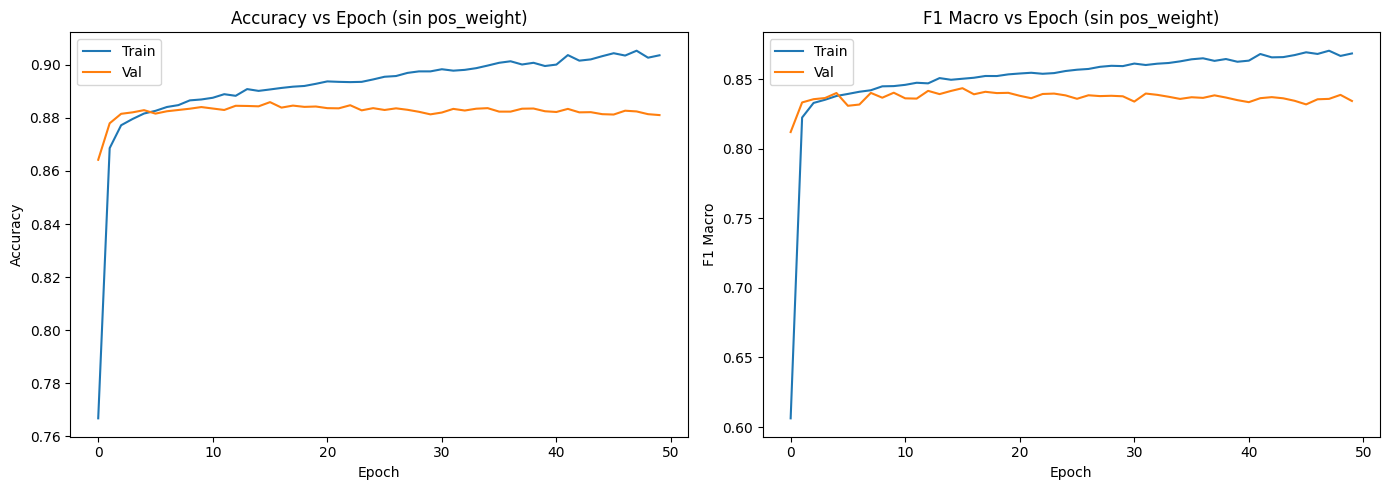

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1["train_acc"], label="Train")
axes[0].plot(history1["val_acc"], label="Val")
axes[0].set_title("Accuracy vs Epoch (sin pos_weight)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history1["train_f1"], label="Train")
axes[1].plot(history1["val_f1"], label="Val")
axes[1].set_title("F1 Macro vs Epoch (sin pos_weight)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Macro")
axes[1].legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.92     10929
        >50K       0.80      0.70      0.75      3629

    accuracy                           0.88     14558
   macro avg       0.85      0.82      0.83     14558
weighted avg       0.88      0.88      0.88     14558



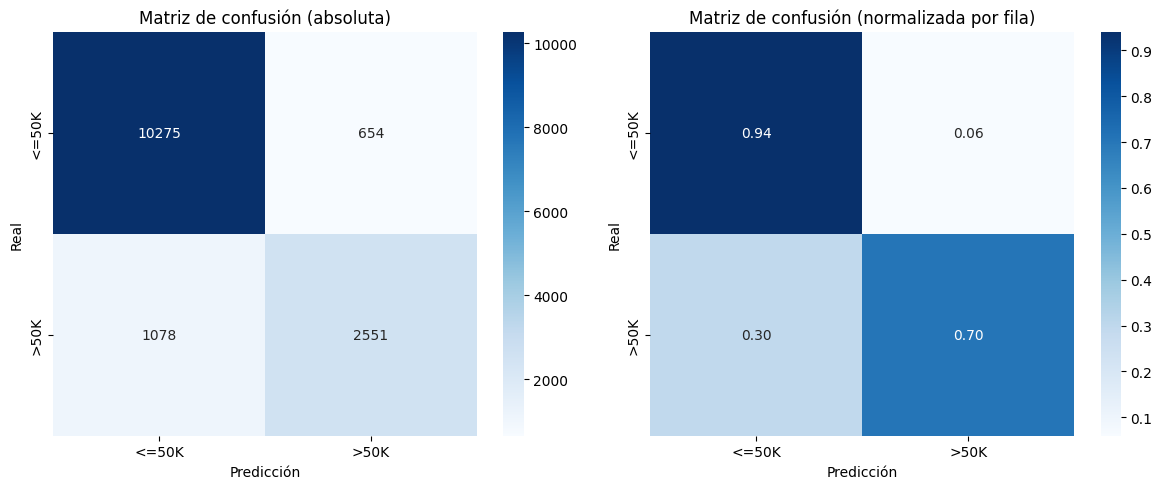

In [61]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model1.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_dense, x_occ, x_country, x_skill, x_edu, y in val_loader:
        logits = model1(
            x_dense.to(device),
            x_occ.to(device),
            x_country.to(device),
            x_skill.to(device),
            x_edu.to(device),
        ).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Podemos ver que el modelo alcanza una accuracy de aproximadamente 88%, pero este número es engañoso debido a que estamos lidiando con un dataset moderadamente desbalanceado. Por ejemplo, un clasificador que predijera <=50k para todos obtendría un 75% aprox. de accuracy sin aprender nada. Tenemos los siguientes resultados:

- <=50k: 0.91 de precision, 0.94 de recall y 0.92 de F1. El modelo identifica correctamente el 94% de los individuos de esta clase. Tiene alto rendimiento con esta clase debido a que es la calse mayoritaria.
- \>=50k: 0.80 de precisión, 0.70 de recall y 0.75 de F1. El modelo falla en detectar un 30% de las personas que realmente ganan >50k, clasificandolos incorrectamente como <=50K (falso negativo).

Veamos el rendimiento usando `pos_weight` de Pytorch


### Experimento 2: con pos_weight (balance de clases)

Se repite el entrenamiento con `BCEWithLogitsLoss(pos_weight=neg/pos)` para penalizar más los errores en la clase minoritaria (>50K).


Epoch  10 | Train acc=0.8629 f1=0.8326 | Val acc=0.8665 f1=0.8333
Epoch  20 | Train acc=0.8680 f1=0.8390 | Val acc=0.8566 f1=0.8246
Epoch  30 | Train acc=0.8761 f1=0.8482 | Val acc=0.8575 f1=0.8248
Epoch  40 | Train acc=0.8778 f1=0.8501 | Val acc=0.8579 f1=0.8245
Epoch  50 | Train acc=0.8810 f1=0.8544 | Val acc=0.8584 f1=0.8256


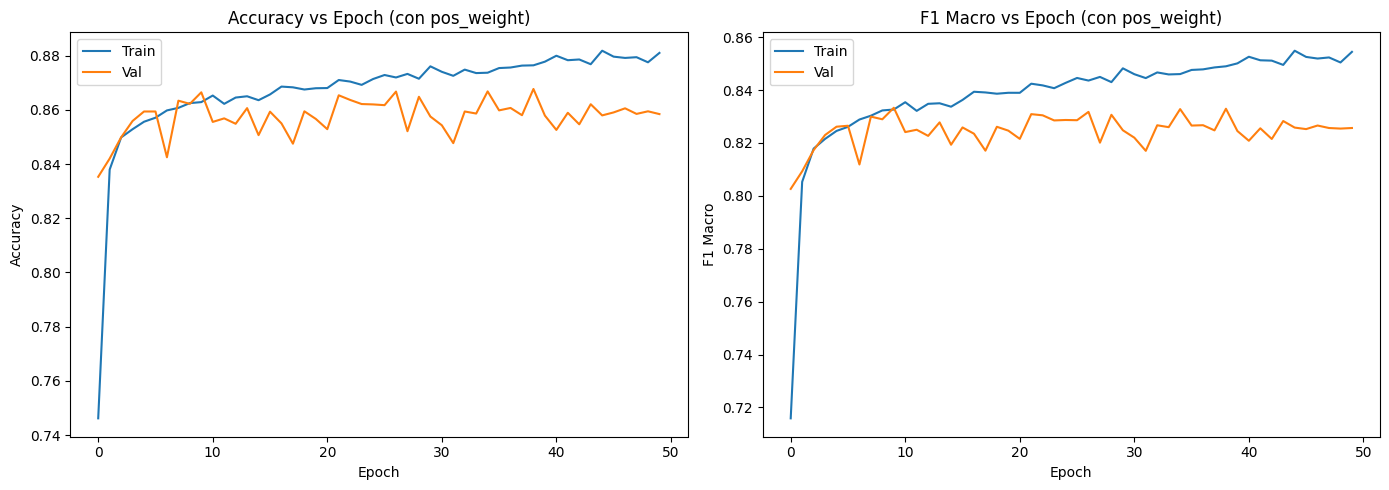

              precision    recall  f1-score   support

       <=50K       0.95      0.86      0.90     10929
        >50K       0.67      0.85      0.75      3629

    accuracy                           0.86     14558
   macro avg       0.81      0.86      0.83     14558
weighted avg       0.88      0.86      0.86     14558



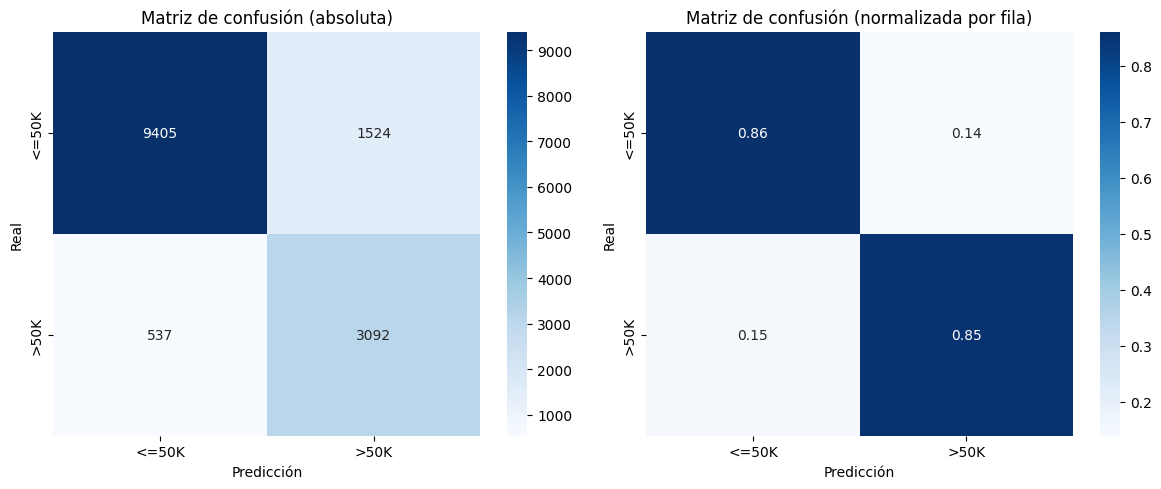

In [62]:
# --- Experimento 2: con pos_weight ---
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight_tensor = torch.tensor([neg / pos], dtype=torch.float32).to(device)

model2 = IncomeModelEmbedding().to(device)
criterion2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)
history2 = {"train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    train_acc, train_f1 = run_epoch(
        train_loader, model2, criterion2, optimizer2, train=True
    )
    val_acc, val_f1 = run_epoch(val_loader, model2, criterion2, optimizer2, train=False)

    history2["train_acc"].append(train_acc)
    history2["val_acc"].append(val_acc)
    history2["train_f1"].append(train_f1)
    history2["val_f1"].append(val_f1)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | Train acc={train_acc:.4f} f1={train_f1:.4f} | Val acc={val_acc:.4f} f1={val_f1:.4f}"
        )

# Curvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history2["train_acc"], label="Train")
axes[0].plot(history2["val_acc"], label="Val")
axes[0].set_title("Accuracy vs Epoch (con pos_weight)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history2["train_f1"], label="Train")
axes[1].plot(history2["val_f1"], label="Val")
axes[1].set_title("F1 Macro vs Epoch (con pos_weight)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Macro")
axes[1].legend()
plt.tight_layout()
plt.show()

# Classification report + confusion matrices
model2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_dense, x_occ, x_country, x_skill, x_edu, y in val_loader:
        logits = model2(
            x_dense.to(device),
            x_occ.to(device),
            x_country.to(device),
            x_skill.to(device),
            x_edu.to(device),
        ).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).cpu().int().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.int().numpy())

print(classification_report(all_labels, all_preds, target_names=["<=50K", ">50K"]))

cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Matriz de confusión (absoluta)", "Matriz de confusión (normalizada por fila)"],
    ["d", ".2f"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

La métrica F1-score se mantuvo en 0.83, lo que indica que la capacidad total del modelo no cambió, solo penaliza más los errores en la clase minoritaria.

El recall de >50k mejoró por 15 (0.70 - 0.85): el modelo detecta ahora el 85% de las personas que realmente ganan >50k, reduciendo bastante los falsos negativos. Sin embargo, tradeoff es una caída de 13 en precisión de >50k (0.80 - 0.67). El modelo es mejor prediciendo >50k pero genera más falsos positivos.

La elección entre ambos experimentos depende del caso de uso.


## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.
